# (Optional) Colab Setup
If you aren't using Colab, you can delete the following code cell. This is just to help students with mounting to Google Drive to access the other .py files and downloading the data, which is a little trickier on Colab than on your local machine using Jupyter. 

In [ ]:
# you will be prompted with a window asking to grant permissions
# from google.colab import drive
# drive.mount("/content/drive")

In [ ]:
# fill in the path in your Google Drive in the string below. Note: do not escape slashes or spaces
# import os
# datadir = "/content/assignment3"
# if not os.path.exists(datadir):
#   !ln -s "/content/drive/My Drive/Your/assignment3/path/" $datadir # TODO: Fill your assignment3 path
# os.chdir(datadir)
# !pwd

# Data Setup

The first thing to do is implement a dataset class to load rotated CIFAR10 images with matching labels. Since there is already a CIFAR10 dataset class implemented in `torchvision`, we will extend this class and modify the `__get_item__` method appropriately to load rotated images.

Each rotation label should be an integer in the set {0, 1, 2, 3} which correspond to rotations of 0, 90, 180, or 270 degrees respectively.

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import random

import matplotlib.pyplot as plt


def rotate_img(img, rot):
    if rot == 0: # 0 degrees rotation
        return img
    # TODO: Implement rotate_img() - return the rotated img
    elif rot == 1 or rot == 2 or rot == 3: # 90, 180, 270 degrees rotation
        return transforms.functional.rotate(img, rot*90)
    else:
        raise ValueError('rotation should be 0, 90, 180, or 270 degrees')


class CIFAR10Rotation(torchvision.datasets.CIFAR10):

    def __init__(self, root, train, download, transform) -> None:
        super().__init__(root=root, train=train, download=download, transform=transform)
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, index: int):
        image, cls_label = super().__getitem__(index)

        # randomly select image rotation
        rotation_label = random.choice([0, 1, 2, 3])
        image_rotated = rotate_img(image, rotation_label)

        rotation_label = torch.tensor(rotation_label).long()
        return image, image_rotated, rotation_label, torch.tensor(cls_label).long()

In [2]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

batch_size = 128

trainset = CIFAR10Rotation(root='./data', train=True,
                                        download=True, transform=transform_train)
print(len(trainset))
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=0)

testset = CIFAR10Rotation(root='./data', train=False,
                                       download=True, transform=transform_test)
print(len(testset))
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=0)

50000
10000


Show some example images and rotated images with labels:

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.9802322e-08..1.0].


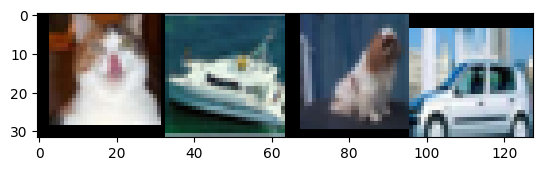

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.9802322e-08..1.0].


Class labels:  cat   ship  dog   car  


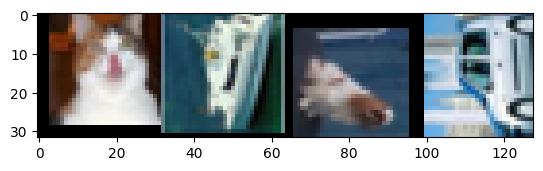

Rotation labels:  0     90    270   90   


In [3]:
classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

rot_classes = ('0', '90', '180', '270')


def imshow(img):
    # unnormalize
    img = transforms.Normalize((0, 0, 0), (1/0.2023, 1/0.1994, 1/0.2010))(img)
    img = transforms.Normalize((-0.4914, -0.4822, -0.4465), (1, 1, 1))(img)
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


dataiter = iter(trainloader)
images, rot_images, rot_labels, labels = next(dataiter)

# print images and rotated images
img_grid = imshow(torchvision.utils.make_grid(images[:4], padding=0))
print('Class labels: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))
img_grid = imshow(torchvision.utils.make_grid(rot_images[:4], padding=0))
print('Rotation labels: ', ' '.join(f'{rot_classes[rot_labels[j]]:5s}' for j in range(4)))

# Evaluation code

In [4]:
# Determine GPU or CPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [5]:
import time

def run_test(net, testloader, criterion, task):
    correct = 0
    total = 0
    avg_test_loss = 0.0
    # since we're not training, we don't need to calculate the gradients for our outputs
    with torch.no_grad():
        for images, images_rotated, labels, cls_labels in testloader:
            if task == 'rotation':
              images, labels = images_rotated.to(device), labels.to(device)
            elif task == 'classification':
              images, labels = images.to(device), cls_labels.to(device)
            # TODO: Calculate outputs by running images through the network
            # The class with the highest energy is what we choose as prediction
            outputs = net(images)
            # Choose the class with the highest energy
            prediction = torch.argmax(outputs, dim=1)
            
            # Update the parameters for calculating the accuracy
            total += labels.size(0)
            correct += (prediction == labels).sum().item()
            
            # loss
            avg_test_loss += criterion(outputs, labels)  / len(testloader)
    print('TESTING:')
    print(f'Accuracy of the network on the 10000 test images: {100 * correct / total:.2f} %')
    print(f'Average loss on the 10000 test images: {avg_test_loss:.3f}')

In [6]:
def adjust_learning_rate(optimizer, epoch, init_lr, decay_epochs=30):
    """Sets the learning rate to the initial LR decayed by 10 every 30 epochs"""
    lr = init_lr * (0.1 ** (epoch // decay_epochs))
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr

## 1. Train a ResNet18 on the rotation task

In this section, we will train a ResNet18 model on the rotation task. The input is a rotated image and the model predicts the rotation label. See the Data Setup section for details.

In [7]:
# Determine GPU or CPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [8]:
import torch.nn as nn
import torch.nn.functional as F

from torchvision.models import resnet18

net = resnet18(num_classes=4)
net = net.to(device)

print(net)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [9]:
import torch.optim as optim

# TODO: Define criterion and optimizer
criterion = nn.CrossEntropyLoss()
# Choose the optimizer as SGD or Adam
# optimizer = torch.optim.SGD(net.parameters())
optimizer = torch.optim.Adam(net.parameters())

In [10]:
# Both the self-supervised rotation task and supervised CIFAR10 classification are
# trained with the CrossEntropyLoss, so we can use the training loop code.

def train(net, criterion, optimizer, num_epochs, decay_epochs, init_lr, task):

    # Set the initial learning rate
    for param_group in optimizer.param_groups:
        param_group['lr'] = init_lr

    for epoch in range(num_epochs):  # loop over the dataset multiple times

        running_loss = 0.0
        running_correct = 0.0
        running_total = 0.0
        start_time = time.time()

        net.train()

        for i, (imgs, imgs_rotated, rotation_label, cls_label) in enumerate(trainloader, 0):
            adjust_learning_rate(optimizer, epoch, init_lr, decay_epochs)

            # TODO: Set the data to the correct device; Different task will use different inputs and labels
            if task == 'rotation':
                images, labels = imgs_rotated.to(device), rotation_label.to(device)
            elif task == 'classification':
                images, labels = imgs.to(device), cls_label.to(device)

            # TODO: Zero the parameter gradients
            optimizer.zero_grad()

            # TODO: forward + backward + optimize
            outputs = net(images)
            # the "outputs" is raw logits without softmax, so directly give it to CrossEntropyLoss() function
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # TODO: Get predicted results
            predicted = torch.argmax(outputs, dim=1)

            # print statistics
            print_freq = 100
            running_loss += loss.item()

            # calc acc
            running_total += labels.size(0)
            running_correct += (predicted == labels).sum().item()

            if i % print_freq == (print_freq - 1):    # print every 2000 mini-batches
                print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / print_freq:.3f} acc: {100*running_correct / running_total:.2f} time: {time.time() - start_time:.2f}')
                running_loss, running_correct, running_total = 0.0, 0.0, 0.0
                start_time = time.time()

        # TODO: Run the run_test() function after each epoch; Set the model to the evaluation mode.
        net.eval()
        run_test(net, testloader, criterion, task)

    print('Finished Training')

In [11]:
# Initial settings: num_epochs=45, decay_epochs=15, init_lr=0.01
train(net, criterion, optimizer, num_epochs=45, decay_epochs=20, init_lr=0.001, task='rotation')

# TODO: Save the model
torch.save(net.state_dict(), 'models/mp3_pretrain_model.pth')

[1,   100] loss: 1.270 acc: 43.15 time: 6.01
[1,   200] loss: 1.140 acc: 50.23 time: 5.90
[1,   300] loss: 1.101 acc: 52.34 time: 5.85
TESTING:
Accuracy of the network on the 10000 test images: 54.66 %
Average loss on the 10000 test images: 1.057
[2,   100] loss: 1.056 acc: 54.57 time: 6.27
[2,   200] loss: 1.036 acc: 55.66 time: 5.80
[2,   300] loss: 1.005 acc: 57.63 time: 5.85
TESTING:
Accuracy of the network on the 10000 test images: 56.35 %
Average loss on the 10000 test images: 1.032
[3,   100] loss: 0.975 acc: 58.95 time: 6.22
[3,   200] loss: 0.953 acc: 60.20 time: 6.30
[3,   300] loss: 0.957 acc: 59.78 time: 6.24
TESTING:
Accuracy of the network on the 10000 test images: 62.98 %
Average loss on the 10000 test images: 0.894
[4,   100] loss: 0.939 acc: 61.30 time: 12.07
[4,   200] loss: 0.919 acc: 61.69 time: 12.95
[4,   300] loss: 0.911 acc: 61.73 time: 13.76
TESTING:
Accuracy of the network on the 10000 test images: 61.55 %
Average loss on the 10000 test images: 0.934
[5,   100

## 2.1 Fine-tuning on the pre-trained model

In this section, we will load the pre-trained ResNet18 model and fine-tune on the classification task. We will freeze all previous layers except for the 'layer4' block and 'fc' layer.

In [49]:
# Determine GPU or CPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [136]:
import torch.nn as nn
import torch.nn.functional as F

from torchvision.models import resnet18

# TODO: Load the pre-trained ResNet18 model
net = resnet18(num_classes=10)

# Keep the backbone of the pre-trained model and change the classifier
backbone = torch.load('models/mp3_pretrain_model.pth')
new_state_dict = net.state_dict()
backbone = {k: v for k, v in backbone.items() if k in new_state_dict and 'fc' not in k}
# backbone = {k: v for k, v in backbone.items() 
#            if k in new_state_dict and not k.startswith('layer4') and not k.startswith('fc')}

# Remain the backbone
new_state_dict.update(backbone)
net.load_state_dict(new_state_dict)

# Refresh the classifier
# net.fc = nn.Linear(512, 10)

net = net.to(device)
print(net)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [51]:
# TODO: Freeze all previous layers; only keep the 'layer4' block and 'fc' layer trainable
# First, freeze all layers
for param in net.parameters():
    param.requires_grad = False

# Next, unfreeze the 'layer4' block and 'fc' layer
for param in net.layer4.parameters():
    param.requires_grad = True
for param in net.fc.parameters():
    param.requires_grad = True

In [52]:
# Print all the trainable parameters
params_to_update = net.parameters()
print("Params to learn:")
params_to_update = []
for name,param in net.named_parameters():
    if param.requires_grad == True:
        params_to_update.append(param)
        print("\t",name)

Params to learn:
	 layer4.0.conv1.weight
	 layer4.0.bn1.weight
	 layer4.0.bn1.bias
	 layer4.0.conv2.weight
	 layer4.0.bn2.weight
	 layer4.0.bn2.bias
	 layer4.0.downsample.0.weight
	 layer4.0.downsample.1.weight
	 layer4.0.downsample.1.bias
	 layer4.1.conv1.weight
	 layer4.1.bn1.weight
	 layer4.1.bn1.bias
	 layer4.1.conv2.weight
	 layer4.1.bn2.weight
	 layer4.1.bn2.bias
	 fc.weight
	 fc.bias


In [53]:
# TODO: Define criterion and optimizer
# Note that your optimizer only needs to update the parameters that are trainable.
criterion = nn.CrossEntropyLoss()
# Only update the parameters that are trainable
trainable_params = filter(lambda p: p.requires_grad, net.parameters())
# optimizer = optim.SGD(trainable_params)
optimizer = optim.Adam(trainable_params)

In [54]:
# Initial settings: num_epochs=20, decay_epochs=10, init_lr=0.01
train(net, criterion, optimizer, num_epochs=35, decay_epochs=15, init_lr=0.005, task='classification')


[1,   100] loss: 1.538 acc: 44.92 time: 5.32
[1,   200] loss: 1.312 acc: 52.92 time: 5.80
[1,   300] loss: 1.251 acc: 55.05 time: 6.01
TESTING:
Accuracy of the network on the 10000 test images: 57.72 %
Average loss on the 10000 test images: 1.172
[2,   100] loss: 1.194 acc: 56.99 time: 11.09
[2,   200] loss: 1.182 acc: 57.31 time: 11.17
[2,   300] loss: 1.167 acc: 58.23 time: 10.89
TESTING:
Accuracy of the network on the 10000 test images: 60.65 %
Average loss on the 10000 test images: 1.083
[3,   100] loss: 1.145 acc: 58.70 time: 10.76
[3,   200] loss: 1.128 acc: 59.32 time: 10.96
[3,   300] loss: 1.100 acc: 60.41 time: 10.87
TESTING:
Accuracy of the network on the 10000 test images: 62.78 %
Average loss on the 10000 test images: 1.070
[4,   100] loss: 1.087 acc: 61.12 time: 10.38
[4,   200] loss: 1.090 acc: 61.05 time: 10.99
[4,   300] loss: 1.089 acc: 60.85 time: 10.90
TESTING:
Accuracy of the network on the 10000 test images: 63.05 %
Average loss on the 10000 test images: 1.056
[5,

In [55]:
# Save the model
torch.save(net.state_dict(), 'models/mp3_part2_pre_model.pth')

## 2.2 Fine-tuning on the randomly initialized model
In this section, we will randomly initialize a ResNet18 model and fine-tune on the classification task. We will freeze all previous layers except for the 'layer4' block and 'fc' layer.

In [56]:
# Determine GPU or CPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [57]:
import torch.nn as nn
import torch.nn.functional as F

from torchvision.models import resnet18

# TODO: Randomly initialize a ResNet18 model
net = resnet18(num_classes=10)
net.to(device)

print(net)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [58]:
# TODO: Freeze all previous layers; only keep the 'layer4' block and 'fc' layer trainable
# To do this, you should set requires_grad=False for the frozen layers.
# First, freeze all layers
for param in net.parameters():
    param.requires_grad = False

# Next, unfreeze the 'layer4' block and 'fc' layer
for param in net.layer4.parameters():
    param.requires_grad = True
for param in net.fc.parameters():
    param.requires_grad = True

In [59]:
# Print all the trainable parameters
params_to_update = net.parameters()
print("Params to learn:")
params_to_update = []
for name,param in net.named_parameters():
    if param.requires_grad == True:
        params_to_update.append(param)
        print("\t",name)

Params to learn:
	 layer4.0.conv1.weight
	 layer4.0.bn1.weight
	 layer4.0.bn1.bias
	 layer4.0.conv2.weight
	 layer4.0.bn2.weight
	 layer4.0.bn2.bias
	 layer4.0.downsample.0.weight
	 layer4.0.downsample.1.weight
	 layer4.0.downsample.1.bias
	 layer4.1.conv1.weight
	 layer4.1.bn1.weight
	 layer4.1.bn1.bias
	 layer4.1.conv2.weight
	 layer4.1.bn2.weight
	 layer4.1.bn2.bias
	 fc.weight
	 fc.bias


In [60]:
# TODO: Define criterion and optimizer
# Note that your optimizer only needs to update the parameters that are trainable.
criterion = nn.CrossEntropyLoss()
# Only update the parameters that are trainable
trainable_params = filter(lambda p: p.requires_grad, net.parameters())
# optimizer = optim.SGD(trainable_params)
optimizer = optim.Adam(trainable_params)

In [61]:
# Initial settings: num_epochs=20, decay_epochs=10, init_lr=0.01
train(net, criterion, optimizer, num_epochs=50, decay_epochs=20, init_lr=0.005, task='classification')

[1,   100] loss: 2.133 acc: 25.90 time: 5.22
[1,   200] loss: 1.918 acc: 30.50 time: 5.93
[1,   300] loss: 1.869 acc: 32.16 time: 6.23
TESTING:
Accuracy of the network on the 10000 test images: 37.84 %
Average loss on the 10000 test images: 1.716
[2,   100] loss: 1.813 acc: 33.95 time: 10.90
[2,   200] loss: 1.772 acc: 35.62 time: 11.01
[2,   300] loss: 1.766 acc: 35.87 time: 10.91
TESTING:
Accuracy of the network on the 10000 test images: 40.99 %
Average loss on the 10000 test images: 1.640
[3,   100] loss: 1.720 acc: 37.34 time: 11.04
[3,   200] loss: 1.725 acc: 38.38 time: 10.82
[3,   300] loss: 1.727 acc: 37.96 time: 10.75
TESTING:
Accuracy of the network on the 10000 test images: 41.14 %
Average loss on the 10000 test images: 1.646
[4,   100] loss: 1.682 acc: 38.82 time: 10.77
[4,   200] loss: 1.692 acc: 38.44 time: 10.78
[4,   300] loss: 1.693 acc: 39.04 time: 10.76
TESTING:
Accuracy of the network on the 10000 test images: 41.16 %
Average loss on the 10000 test images: 1.616
[5,

In [62]:
# Save the model
torch.save(net.state_dict(), 'models/mp3_part2_ram_model.pth')

## 3.1 Supervised training on the pre-trained model
In this section, we will load the pre-trained ResNet18 model and re-train the whole model on the classification task.

In [44]:
# Determine GPU or CPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [137]:
import torch.nn as nn
import torch.nn.functional as F

from torchvision.models import resnet18

# TODO: Load the pre-trained ResNet18 model
net = resnet18(num_classes=10)

# Keep the backbone of the pre-trained model and change the classifier
backbone = torch.load('models/mp3_pretrain_model.pth')
new_state_dict = net.state_dict()
backbone = {k: v for k, v in backbone.items() if k in new_state_dict and 'fc' not in k}

# Remain the backbone
new_state_dict.update(backbone)
net.load_state_dict(new_state_dict)

# Refresh the classifier
# net.fc = nn.Linear(512, 10)

net = net.to(device)
print(net)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [46]:
# TODO: Define criterion and optimizer
criterion = nn.CrossEntropyLoss()
# optimizer = optim.SGD(net.parameters())
optimizer = optim.Adam(net.parameters())

In [47]:
# Initial settings: num_epochs=20, decay_epochs=10, init_lr=0.01
train(net, criterion, optimizer, num_epochs=35, decay_epochs=15, init_lr=0.005, task='classification')

[1,   100] loss: 1.648 acc: 40.34 time: 6.01
[1,   200] loss: 1.319 acc: 53.87 time: 6.15
[1,   300] loss: 1.191 acc: 57.62 time: 5.94
TESTING:
Accuracy of the network on the 10000 test images: 63.71 %
Average loss on the 10000 test images: 1.026
[2,   100] loss: 1.023 acc: 63.81 time: 6.71
[2,   200] loss: 1.036 acc: 63.75 time: 6.28
[2,   300] loss: 0.946 acc: 67.32 time: 6.24
TESTING:
Accuracy of the network on the 10000 test images: 67.86 %
Average loss on the 10000 test images: 0.927
[3,   100] loss: 0.864 acc: 69.95 time: 6.58
[3,   200] loss: 0.867 acc: 70.18 time: 6.35
[3,   300] loss: 0.869 acc: 69.95 time: 6.38
TESTING:
Accuracy of the network on the 10000 test images: 73.37 %
Average loss on the 10000 test images: 0.774
[4,   100] loss: 0.800 acc: 72.21 time: 6.45
[4,   200] loss: 0.794 acc: 72.45 time: 8.73
[4,   300] loss: 0.769 acc: 73.40 time: 13.27
TESTING:
Accuracy of the network on the 10000 test images: 73.39 %
Average loss on the 10000 test images: 0.771
[5,   100] 

In [48]:
# Save the model
torch.save(net.state_dict(), 'models/mp3_part3_pre_model.pth')

## 3.2 Supervised training on the randomly initialized model
In this section, we will randomly initialize a ResNet18 model and re-train the whole model on the classification task.

In [38]:
# Determine GPU or CPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [39]:
import torch.nn as nn
import torch.nn.functional as F

from torchvision.models import resnet18

# TODO: Randomly initialize a ResNet18 model
net = resnet18(num_classes=10)
net = net.to(device)

print(net)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [41]:
# TODO: Define criterion and optimizer
criterion = nn.CrossEntropyLoss()
# optimizer = optim.SGD(net.parameters())
optimizer = optim.Adam(net.parameters())

In [42]:
# Initial settings: num_epochs=20, decay_epochs=10, init_lr=0.01
train(net, criterion, optimizer, num_epochs=35, decay_epochs=15, init_lr=0.005, task='classification')

[1,   100] loss: 2.047 acc: 26.05 time: 6.35
[1,   200] loss: 1.713 acc: 37.55 time: 11.68
[1,   300] loss: 1.594 acc: 42.45 time: 12.78
TESTING:
Accuracy of the network on the 10000 test images: 44.57 %
Average loss on the 10000 test images: 1.724
[2,   100] loss: 1.616 acc: 42.98 time: 12.43
[2,   200] loss: 1.472 acc: 47.12 time: 12.77
[2,   300] loss: 1.395 acc: 49.46 time: 12.56
TESTING:
Accuracy of the network on the 10000 test images: 54.25 %
Average loss on the 10000 test images: 1.253
[3,   100] loss: 1.231 acc: 55.64 time: 12.66
[3,   200] loss: 1.176 acc: 57.81 time: 12.97
[3,   300] loss: 1.147 acc: 59.17 time: 9.54
TESTING:
Accuracy of the network on the 10000 test images: 62.71 %
Average loss on the 10000 test images: 1.045
[4,   100] loss: 1.067 acc: 61.72 time: 6.27
[4,   200] loss: 1.053 acc: 62.86 time: 5.91
[4,   300] loss: 0.995 acc: 64.70 time: 5.96
TESTING:
Accuracy of the network on the 10000 test images: 66.07 %
Average loss on the 10000 test images: 0.960
[5,  

In [43]:
# Save the model
torch.save(net.state_dict(), 'models/mp3_part3_ram_model.pth')

## 4.1 Further improvement on rotation task

In [106]:
# Determine GPU or CPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [107]:
import torch.nn as nn
import torch.nn.functional as F

from torchvision.models import resnet50

net = resnet50(num_classes=4)
# The resent50 model is much deeper than resnet18, and is pretrained on ImageNet.
# So, we adjust the 'conv1' layer and 'maxpool' layer
net.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)

net = net.to(device)
print(net)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [108]:
import torch.optim as optim

# Define criterion and optimizer]
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(net.parameters(), weight_decay=1e-4)

In [109]:
train(net, criterion, optimizer, num_epochs=60, decay_epochs=20, init_lr=1e-3, task='rotation')

[1,   100] loss: 1.468 acc: 37.24 time: 13.79
[1,   200] loss: 1.226 acc: 48.50 time: 13.27
[1,   300] loss: 1.162 acc: 51.05 time: 13.29
TESTING:
Accuracy of the network on the 10000 test images: 55.94 %
Average loss on the 10000 test images: 1.051
[2,   100] loss: 1.059 acc: 54.96 time: 20.49
[2,   200] loss: 1.038 acc: 55.55 time: 24.75
[2,   300] loss: 0.990 acc: 58.60 time: 31.39
TESTING:
Accuracy of the network on the 10000 test images: 57.97 %
Average loss on the 10000 test images: 1.006
[3,   100] loss: 0.979 acc: 58.84 time: 14.56
[3,   200] loss: 0.978 acc: 58.97 time: 13.17
[3,   300] loss: 0.961 acc: 59.96 time: 13.15
TESTING:
Accuracy of the network on the 10000 test images: 61.88 %
Average loss on the 10000 test images: 0.903
[4,   100] loss: 0.903 acc: 62.19 time: 23.93
[4,   200] loss: 0.884 acc: 62.84 time: 27.61
[4,   300] loss: 0.874 acc: 64.11 time: 28.03
TESTING:
Accuracy of the network on the 10000 test images: 63.78 %
Average loss on the 10000 test images: 0.903


In [110]:
# Save the model
torch.save(net.state_dict(), 'models/mp3_part4_pretrain_model.pth')

## 4.2 Supervised training on the new pre-trained model

In [150]:
# Determine GPU or CPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [151]:
import torch.nn as nn
import torch.nn.functional as F

from torchvision.models import resnet50

# Load the pre-trained ResNet50 model
net = resnet50(num_classes=10)
net.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)

# Keep the backbone of the pre-trained model and change the classifier
backbone = torch.load('models/mp3_part4_pretrain_model.pth')
new_state_dict = net.state_dict()
backbone = {k: v for k, v in backbone.items() if k in new_state_dict and 'fc' not in k}

# Remain the backbone
new_state_dict.update(backbone)
net.load_state_dict(new_state_dict)

# Refresh the classifier
# net.fc = nn.Linear(2048, 10)

net = net.to(device)
print(net)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [152]:
import torch.optim as optim

# Define criterion and optimizer])
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = torch.optim.AdamW(net.parameters(), weight_decay=1e-4)

In [153]:
train(net, criterion, optimizer, num_epochs=20, decay_epochs=10, init_lr=1e-3, task='classification')

[1,   100] loss: 1.435 acc: 52.38 time: 13.27
[1,   200] loss: 1.075 acc: 68.80 time: 15.73
[1,   300] loss: 0.990 acc: 72.37 time: 18.18
TESTING:
Accuracy of the network on the 10000 test images: 73.45 %
Average loss on the 10000 test images: 0.964
[2,   100] loss: 0.865 acc: 76.85 time: 17.66
[2,   200] loss: 0.860 acc: 77.82 time: 12.77
[2,   300] loss: 0.828 acc: 78.77 time: 12.79
TESTING:
Accuracy of the network on the 10000 test images: 79.63 %
Average loss on the 10000 test images: 0.796
[3,   100] loss: 0.765 acc: 81.15 time: 12.85
[3,   200] loss: 0.745 acc: 82.16 time: 12.86
[3,   300] loss: 0.737 acc: 82.78 time: 12.86
TESTING:
Accuracy of the network on the 10000 test images: 80.83 %
Average loss on the 10000 test images: 0.773
[4,   100] loss: 0.708 acc: 83.32 time: 12.76
[4,   200] loss: 0.708 acc: 83.66 time: 12.72
[4,   300] loss: 0.695 acc: 83.65 time: 12.80
TESTING:
Accuracy of the network on the 10000 test images: 81.92 %
Average loss on the 10000 test images: 0.764


In [154]:
# Save the model
torch.save(net.state_dict(), 'models/mp3_part4_downstream_model.pth')